In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

P = Path("../data/processed")
s = pd.read_parquet(P / "house1_washing_machine.parquet")["watts"]
jobs = pd.read_csv(P / "jobs.csv", parse_dates=["start", "end"])
jobs = jobs[(jobs.house == "H01") & (jobs.appliance == "washing_machine")]

print(len(s), "minutes of data;", len(jobs), "jobs")
jobs.head()

Matplotlib is building the font cache; this may take a moment.


2345468 minutes of data; 1403 jobs


,house,appliance,start,end,duration_min,energy_kwh,avg_kw,peak_kw
0,H01,washing_machine,2012-11-10 10:24:00,2012-11-10 11:57:00,94,0.7637,0.4874,2.0528
1,H01,washing_machine,2012-11-11 14:11:00,2012-11-11 15:45:00,95,0.7154,0.4518,2.1355
2,H01,washing_machine,2012-11-11 19:34:00,2012-11-11 21:09:00,96,0.7715,0.4822,1.9738
3,H01,washing_machine,2012-11-13 16:01:00,2012-11-13 17:35:00,95,0.7621,0.4813,1.9352
4,H01,washing_machine,2012-11-14 13:45:00,2012-11-14 15:17:00,93,0.6901,0.4452,2.1492


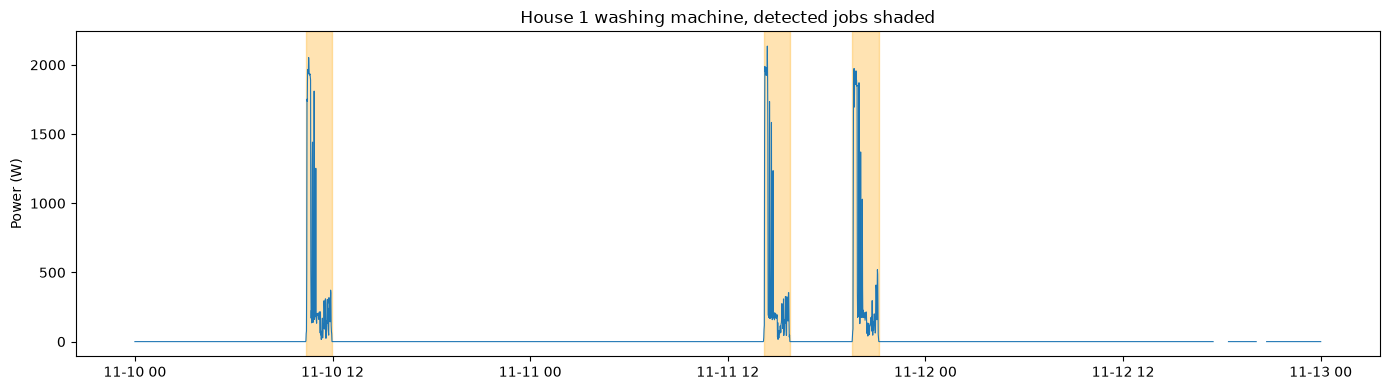

In [2]:
day0 = jobs.start.iloc[0].normalize()
window = s[day0 : day0 + pd.Timedelta(days=3)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(window.index, window.values, lw=0.8)
for _, j in jobs[(jobs.start >= day0) & (jobs.start < day0 + pd.Timedelta(days=3))].iterrows():
    ax.axvspan(j.start, j.end, color="orange", alpha=0.3)
ax.set_ylabel("Power (W)")
ax.set_title("House 1 washing machine, detected jobs shaded")
plt.tight_layout()
plt.show()

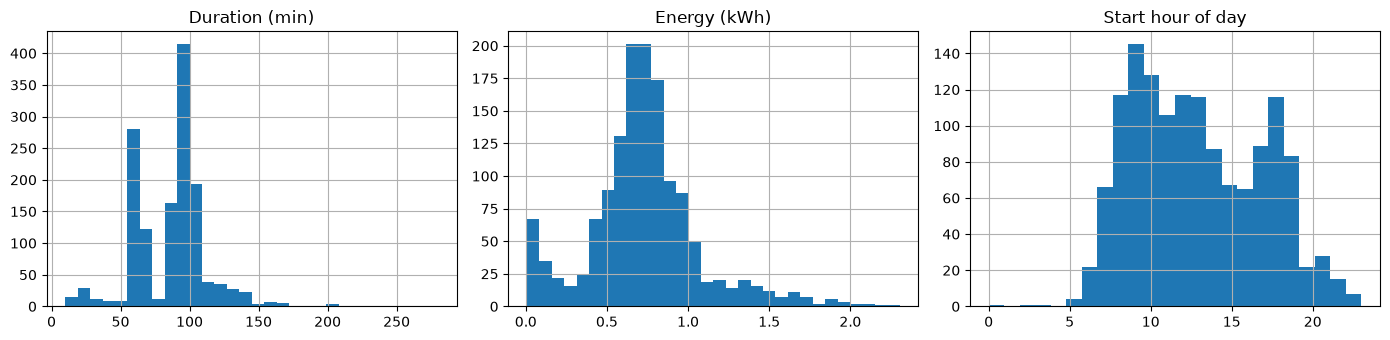

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
jobs.duration_min.hist(ax=axes[0], bins=30); axes[0].set_title("Duration (min)")
jobs.energy_kwh.hist(ax=axes[1], bins=30);   axes[1].set_title("Energy (kWh)")
jobs.start.dt.hour.hist(ax=axes[2], bins=24); axes[2].set_title("Start hour of day")
plt.tight_layout()
plt.show()